<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Histogram**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab, you will perform the following:


- Visualize the distribution of data using histograms.

- Visualize relationships between features.

- Explore data composition and comparisons.


## Demo: Working with database


#### Download the database file.


In [ ]:
!wget -O survey-data.sqlite https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

#### Install the required libraries and import them


In [ ]:
!pip install pandas
!pip install pandas 

In [2]:
!pip install matplotlib
!pip install matplotlib 

In [2]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

#### Connect to the SQLite database


In [3]:
conn = sqlite3.connect('survey-data.sqlite')
conn =  sqlite3.connect('survey-data.sqlite')

## Demo: Basic SQL queries

**Demo 1: Count the number of rows in the table**


In [8]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("survey-data.sqlite")

QUERY = """
SELECT *
FROM main
LIMIT 5
"""

df = pd.read_sql_query(QUERY, conn)
print(df)

conn.close()

   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

**Demo 2: List all tables**


In [9]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("survey-data.sqlite")

QUERY = """
SELECT name AS Table_Name
FROM sqlite_master
WHERE type = 'table';
"""

df = pd.read_sql_query(QUERY, conn)

print(df)

conn.close()

  Table_Name
0       main


**Demo 3: Group data by age**


In [16]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("survey-data.sqlite")

QUERY = """
SELECT name AS Table_Name
FROM sqlite_master
WHERE type = 'table';
"""
df = pd.read_sql_query(QUERY, conn)


## Hands-on Lab: Visualizing Data with Histograms


### 1. Visualizing the distribution of data (Histograms)


**1.1 Histogram of `CompTotal` (Total Compensation)**


Objective: Plot a histogram of `CompTotal` to visualize the distribution of respondents' total compensation.


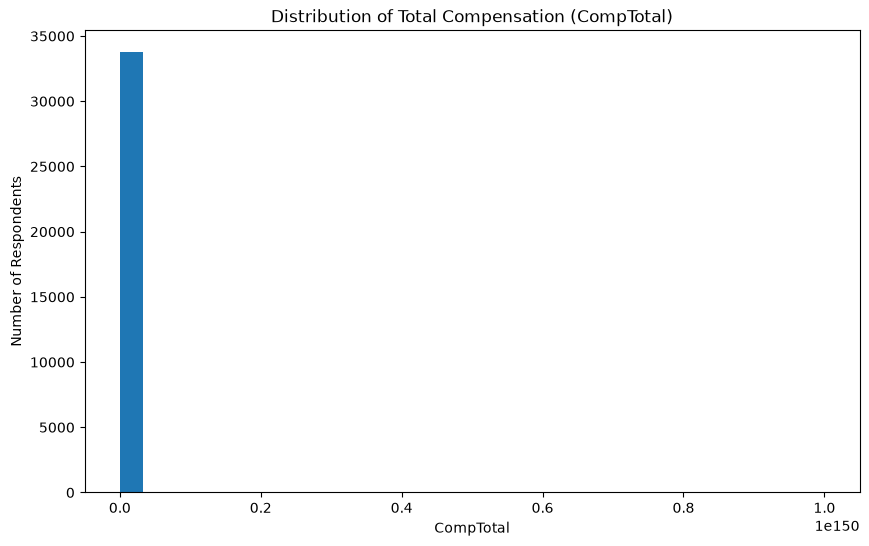

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(url)

df["CompTotal"] = pd.to_numeric(df["CompTotal"], errors="coerce")

comp_data = df["CompTotal"].dropna()


plt.figure(figsize=(10, 6))
plt.hist(comp_data, bins=30)

plt.title("Distribution of Total Compensation (CompTotal)")
plt.xlabel("CompTotal")
plt.ylabel("Number of Respondents")

plt.show()

**1.2 Histogram of YearsCodePro (Years of Professional Coding Experience)**


Objective: Plot a histogram of `YearsCodePro` to analyze the distribution of coding experience among respondents.


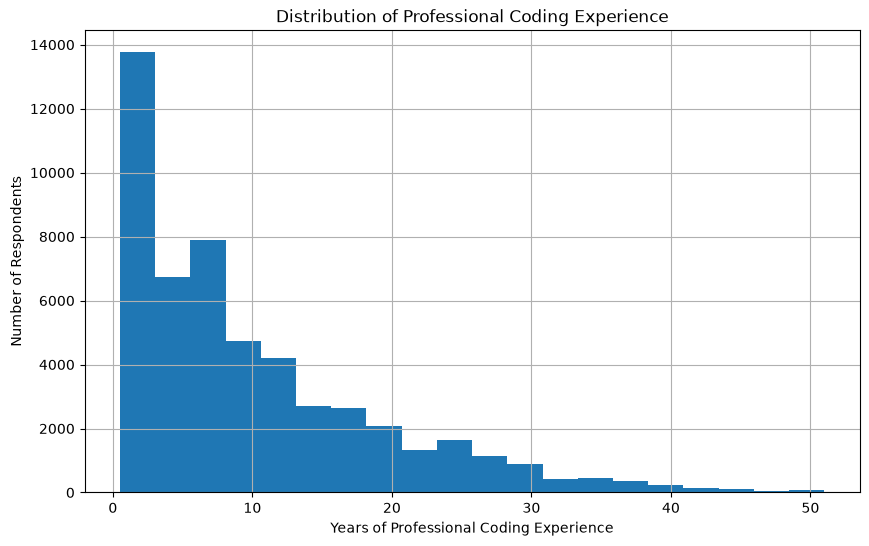

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(url)

df["YearsCodePro"] = df["YearsCodePro"].replace({
    "Less than 1 year": 0.5,
    "More than 50 years": 51
})

df["YearsCodePro"] = pd.to_numeric(df["YearsCodePro"], errors="coerce")

years = df["YearsCodePro"].dropna()

plt.figure(figsize=(10, 6))
plt.hist(years, bins=20)

plt.title("Distribution of Professional Coding Experience")
plt.xlabel("Years of Professional Coding Experience")
plt.ylabel("Number of Respondents")

plt.grid(True)
plt.show()

### 2. Visualizing Relationships in Data


**2.1 Histogram Comparison of `CompTotal` by `Age` Group**


Objective: Use histograms to compare the distribution of CompTotal across different Age groups.


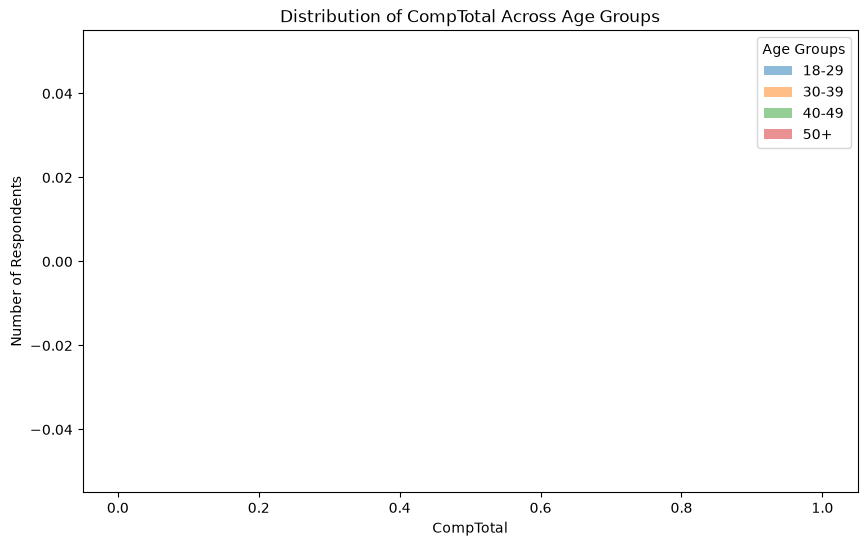

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(url)

df["Age"] = pd.to_numeric(df["Age"], errors="coerce")
df["CompTotal"] = pd.to_numeric(df["CompTotal"], errors="coerce")

df = df.dropna(subset=["Age", "CompTotal"])

df = df[(df["CompTotal"] > 0) & (df["CompTotal"] < 1000000)]

age_groups = {
    "18-29": df[(df["Age"] >= 18) & (df["Age"] <= 29)]["CompTotal"],
    "30-39": df[(df["Age"] >= 30) & (df["Age"] <= 39)]["CompTotal"],
    "40-49": df[(df["Age"] >= 40) & (df["Age"] <= 49)]["CompTotal"],
    "50+": df[df["Age"] >= 50]["CompTotal"]
}

plt.figure(figsize=(10, 6))

for label, data in age_groups.items():
    plt.hist(data, bins=30, alpha=0.5, label=label)

plt.title("Distribution of CompTotal Across Age Groups")
plt.xlabel("CompTotal")
plt.ylabel("Number of Respondents")
plt.legend(title="Age Groups")

plt.show()

**2.2 Histogram of TimeSearching for Different Age Groups**


Objective: Use histograms to explore the distribution of `TimeSearching` (time spent searching for information) for respondents across different age groups.


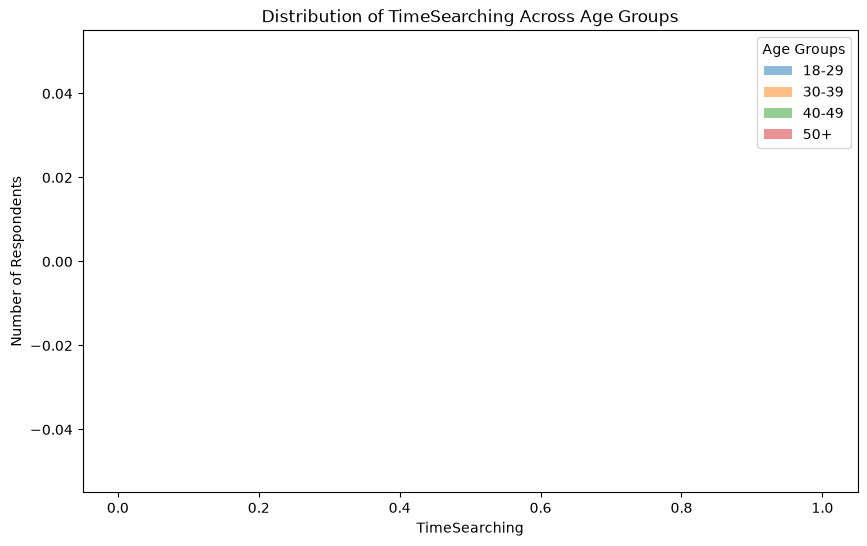

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(url)

df["Age"] = pd.to_numeric(df["Age"], errors="coerce")
df["TimeSearching"] = pd.to_numeric(df["TimeSearching"], errors="coerce")

df = df.dropna(subset=["Age", "TimeSearching"])

age_18_29 = df[(df["Age"] >= 18) & (df["Age"] <= 29)]["TimeSearching"]
age_30_39 = df[(df["Age"] >= 30) & (df["Age"] <= 39)]["TimeSearching"]
age_40_49 = df[(df["Age"] >= 40) & (df["Age"] <= 49)]["TimeSearching"]
age_50_plus = df[df["Age"] >= 50]["TimeSearching"]


plt.figure(figsize=(10, 6))

plt.hist(age_18_29, bins=20, alpha=0.5, label="18-29")
plt.hist(age_30_39, bins=20, alpha=0.5, label="30-39")
plt.hist(age_40_49, bins=20, alpha=0.5, label="40-49")
plt.hist(age_50_plus, bins=20, alpha=0.5, label="50+")

plt.title("Distribution of TimeSearching Across Age Groups")
plt.xlabel("TimeSearching")
plt.ylabel("Number of Respondents")
plt.legend(title="Age Groups")

plt.show()

### 3. Visualizing the Composition of Data


**3.1 Histogram of Most Desired Databases (`DatabaseWantToWorkWith`)**


Objective: Visualize the most desired databases for future learning using a histogram of the top 5 databases.


Text(0, 0.5, 'Number of Respondents')

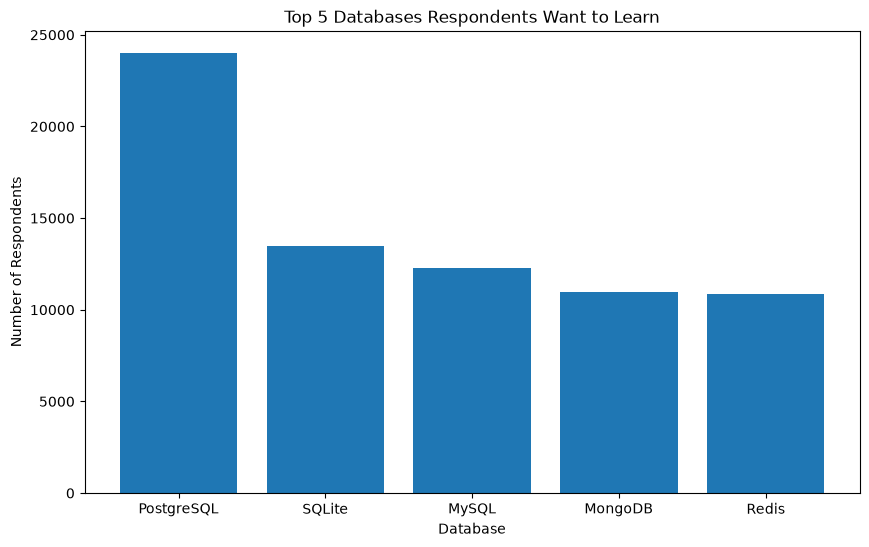

In [21]:
import pandas as pd
import matplotlib.pyplot as plt


url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(url)

db_data = df["DatabaseWantToWorkWith"].dropna()

top_databases = (
    db_data.str.split(";")
           .explode()
           .value_counts()
           .head(5)
)

plt.figure(figsize=(10, 6))
plt.bar(top_databases.index, top_databases.values)

plt.title("Top 5 Databases Respondents Want to Learn")
plt.xlabel("Database")
plt.ylabel("Number of Respondents")

**3.2 Histogram of Preferred Work Locations (`RemoteWork`)**


Objective: Use a histogram to explore the distribution of preferred work arrangements (`remote work`).


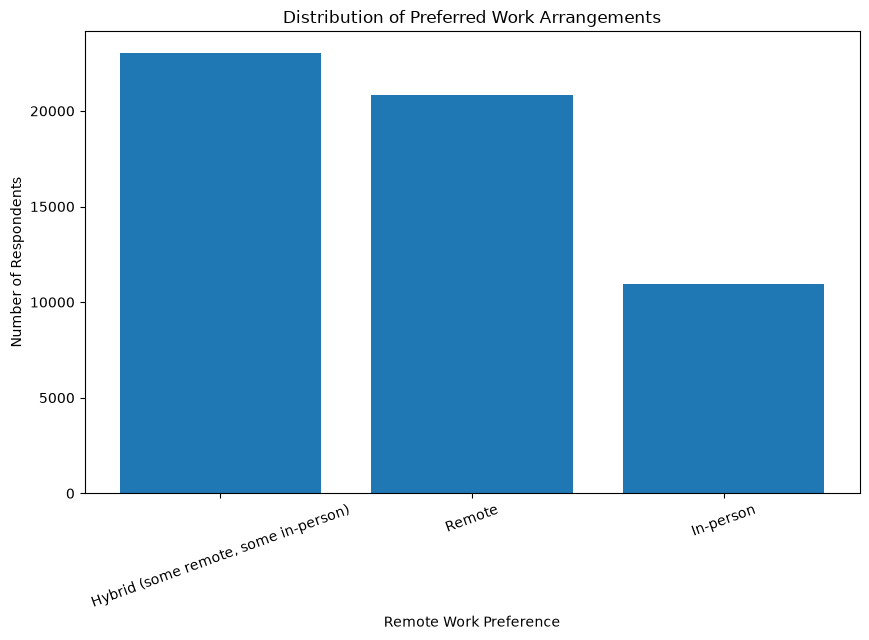

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(url)

remote_counts = df["RemoteWork"].value_counts()

plt.figure(figsize=(10, 6))
plt.bar(remote_counts.index, remote_counts.values)

plt.title("Distribution of Preferred Work Arrangements")
plt.xlabel("Remote Work Preference")
plt.ylabel("Number of Respondents")

plt.xticks(rotation=20)

plt.show()

### 4. Visualizing Comparison of Data


**4.1 Histogram of Median CompTotal for Ages 45 to 60**


Objective: Plot the histogram for `CompTotal` within the age group 45 to 60 to analyze compensation distribution among mid-career respondents.


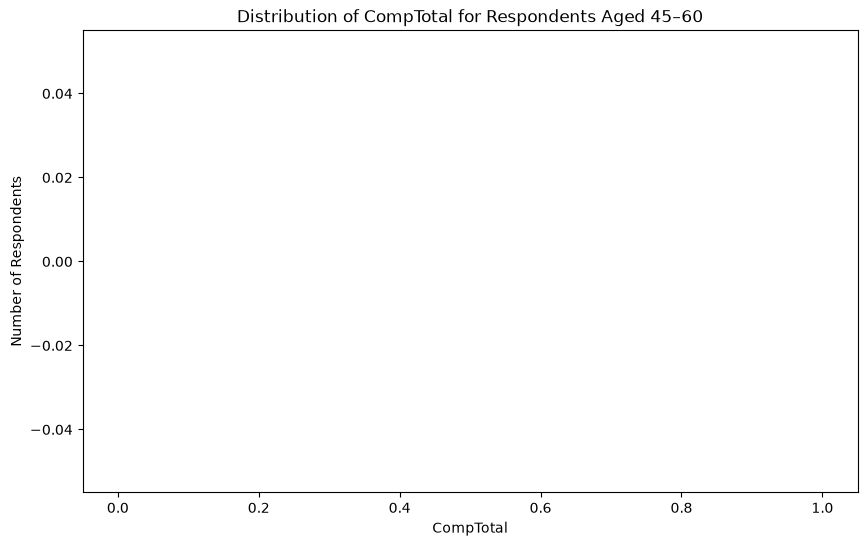

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(url)

df["Age"] = pd.to_numeric(df["Age"], errors="coerce")
df["CompTotal"] = pd.to_numeric(df["CompTotal"], errors="coerce")

df_age = df[(df["Age"] >= 45) & (df["Age"] <= 60)]

comp_data = df_age["CompTotal"].dropna()
comp_data = comp_data[comp_data > 0]

plt.figure(figsize=(10, 6))
plt.hist(comp_data, bins=30)

plt.title("Distribution of CompTotal for Respondents Aged 45–60")
plt.xlabel("CompTotal")
plt.ylabel("Number of Respondents")

plt.show()

**4.2 Histogram of Job Satisfaction (`JobSat`) by YearsCodePro**


Objective: Plot the histogram for `JobSat` scores based on respondents' years of professional coding experience.


<function matplotlib.pyplot.show(close=None, block=None)>

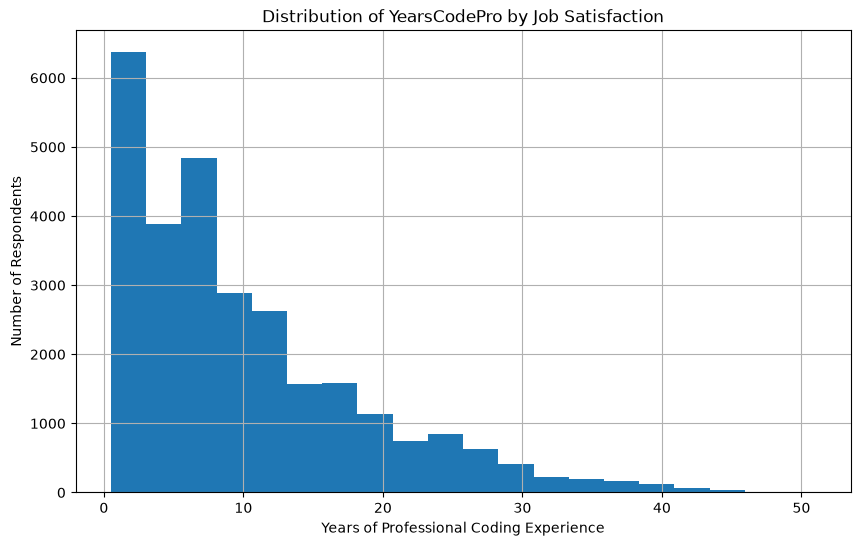

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(url)

df["YearsCodePro"] = df["YearsCodePro"].replace({
    "Less than 1 year": 0.5,
    "More than 50 years": 51
})
df["YearsCodePro"] = pd.to_numeric(df["YearsCodePro"], errors="coerce")

df["JobSatScore"] = pd.to_numeric(df["JobSat"], errors="coerce")

if df["JobSatScore"].isna().all():
    jobsat_mapping = {
        "Very dissatisfied": 1,
        "Dissatisfied": 2,
        "Neither satisfied nor dissatisfied": 3,
        "Satisfied": 4,
        "Very satisfied": 5
    }
    df["JobSatScore"] = df["JobSat"].map(jobsat_mapping)

df = df.dropna(subset=["YearsCodePro", "JobSatScore"])

plt.figure(figsize=(10,6))

plt.hist(
    df["YearsCodePro"],
    bins=20
)

plt.title("Distribution of YearsCodePro by Job Satisfaction")
plt.xlabel("Years of Professional Coding Experience")
plt.ylabel("Number of Respondents")

plt.grid(True)

plt.show

### Final step: Close the database connection


Once you've completed the lab, make sure to close the connection to the SQLite database:



In [26]:
conn.close() 

### Summary


In this lab, you used histograms to visualize various aspects of the dataset, focusing on:

- Distribution of compensation, coding experience, and work hours.

- Relationships in compensation across age groups and work status.

- Composition of data by desired databases and work environments.

- Comparisons of job satisfaction across years of experience.

Histograms helped reveal patterns and distributions in the data, enhancing your understanding of developer demographics and preferences.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
